## **Airbnb Hotel Booking Analysis**
#### Performs data cleaning, Exploratory Data Analysis (EDA), answers the project questions, and generates visualizations.




In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 200)
plt.rcParams['figure.figsize'] = (10,6)
sns.set_style('whitegrid')


In [46]:
import pandas as pd

file_path = '/content/1730285881-Airbnb_Open_Data.xlsx'

try:
    df = pd.read_excel(file_path, engine='openpyxl')
except Exception as e:
    print("Excel read failed:", e)
    print("Trying as CSV instead...")
    df = pd.read_csv(file_path, encoding='utf-8', on_bad_lines='skip')

print("✅ Loaded successfully — shape:", df.shape)
df.head()



✅ Loaded successfully — shape: (102599, 26)


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,country code,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,0.0,strict,Private room,2020.0,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like your home to be treated. No smoking.,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,0.0,moderate,Entire home/apt,2007.0,142.0,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the pet you are planning on bringing with you is OK. I have a cute and quiet mixed chihuahua. I could accept more guests (for an extra fee) but this also...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,US,1.0,flexible,Private room,2005.0,620.0,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and laundry facilities. There is no additional charge to use the washer/dryer in the basement. No smoking, inside or outside. Come home as late as you w...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,US,1.0,moderate,Entire home/apt,2005.0,368.0,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,0.0,moderate,Entire home/apt,2009.0,204.0,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on the property (you can go to the nearby corner). Reasonable quiet after 10:30 pm. Please remove shoes in the house.",NaN


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102599 non-null  int64         
 1   NAME                            102329 non-null  object        
 2   host id                         102599 non-null  int64         
 3   host_identity_verified          102310 non-null  object        
 4   host name                       102191 non-null  object        
 5   neighbourhood group             102570 non-null  object        
 6   neighbourhood                   102583 non-null  object        
 7   lat                             102591 non-null  float64       
 8   long                            102591 non-null  float64       
 9   country                         102067 non-null  object        
 10  country code                    102468 non-null  object 

## Data Cleaning (wrangling)

1. Drop duplicates
2. Drop columns with insufficient data (e.g., 'house rules', 'license' if present)
3. Clean currency columns (remove $ and commas) and convert to numeric
4. Fix typos in categorical columns (e.g., 'brookin' -> 'Brooklyn')
5. Handle missing values (drop or impute depending on column)
6. Convert columns to appropriate dtypes (dates, ints, floats, strings)
7. Remove / cap outliers (brief handling for availability_365)


In [30]:
df_clean = df.copy()

# 1) Drop duplicates
pre_dup = df_clean.shape[0]
df_clean.drop_duplicates(inplace=True)
post_dup = df_clean.shape[0]
print(f"Dropped {pre_dup-post_dup} duplicate rows.")

# 2) Drop columns with mostly missing / insufficient data: check common names
cols_to_drop = []
for candidate in ['house rules', 'license', 'License', 'house_rules', 'licence']:
    if candidate in df_clean.columns:
        cols_to_drop.append(candidate)

if cols_to_drop:
    df_clean.drop(columns=cols_to_drop, inplace=True)
    print('Dropped columns:', cols_to_drop)

# 3) Inspect price-like columns and clean them
possible_price_cols = [c for c in df_clean.columns if 'price' in c.lower() or 'service' in c.lower()]
print('Price-like columns found:', possible_price_cols)

def clean_currency(col):
    if col in df_clean.columns and df_clean[col].dtype == object:
        df_clean[col] = df_clean[col].astype(str).str.replace('$','', regex=False).str.replace(',','', regex=False).str.strip()
        df_clean.loc[df_clean[col].str.strip()=='', col] = pd.NA
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

for c in possible_price_cols:
    try:
        clean_currency(c)
    except Exception as e:
        print('Error cleaning', c, e)

# 4) Fix common typos: neighbourhood group examples
if 'neighbourhood group' in df_clean.columns:
    df_clean['neighbourhood group'] = df_clean['neighbourhood group'].astype(str).str.strip().replace({'brookin':'Brooklyn','Brookin':'Brooklyn','BROOKIN':'Brooklyn'})

# 5) Convert columns: last review to datetime, ids to string
for col in ['last review','last_review','Last review','last_review ']:
    if col in df_clean.columns:
        df_clean.rename(columns={col:'last_review'}, inplace=True)
        break

if 'last_review' in df_clean.columns:
    df_clean['last_review'] = pd.to_datetime(df_clean['last_review'], errors='coerce')

# ensure id and host id exist and are strings if present
if 'id' in df_clean.columns:
    try:
        df_clean['id'] = df_clean['id'].astype('Int64').astype(str)
    except Exception:
        df_clean['id'] = df_clean['id'].astype(str)
if 'host id' in df_clean.columns:
    try:
        df_clean['host id'] = df_clean['host id'].astype('Int64').astype(str)
    except Exception:
        df_clean['host id'] = df_clean['host id'].astype(str)

# 6) Remove rows that lack price info (if a price column exists)
price_cols = [c for c in df_clean.columns if 'price' in c.lower() and 'service' not in c.lower()]
if price_cols:
    df_clean = df_clean.dropna(subset=[price_cols[0]])

# 7) Handle availability_365 outliers: if column exists, clip to 0-365
avail_cols = [c for c in df_clean.columns if 'availability' in c.lower() or 'availability_365' in c.lower()]
if avail_cols:
    ac = avail_cols[0]
    df_clean[ac] = pd.to_numeric(df_clean[ac], errors='coerce')
    df_clean.loc[df_clean[ac] < 0, ac] = 0
    df_clean.loc[df_clean[ac] > 365, ac] = 365

print('After cleaning shape:', df_clean.shape)
df_clean.info()


Dropped 541 duplicate rows.
Dropped columns: ['license', 'house_rules']
Price-like columns found: ['price', 'service fee']
After cleaning shape: (101811, 24)
<class 'pandas.core.frame.DataFrame'>
Index: 101811 entries, 0 to 102057
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              101811 non-null  object        
 1   NAME                            101544 non-null  object        
 2   host id                         101811 non-null  object        
 3   host_identity_verified          101526 non-null  object        
 4   host name                       101410 non-null  object        
 5   neighbourhood group             101811 non-null  object        
 6   neighbourhood                   101796 non-null  object        
 7   lat                             101803 non-null  float64       
 8   long                            101803 no

In [31]:
df_clean.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,101811,101811,57367417,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,101544,61134,Home away from home,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host id,101811,101810,29531702698,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_identity_verified,101526,2,unconfirmed,50831,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host name,101410,13175,Michael,874,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood group,101811,8,Manhattan,43447,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,101796,224,Bedford-Stuyvesant,7882,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,101803.0,NaN,NaN,NaN,40.728094,40.49979,40.688715,40.72228,40.76277,40.91697,0.055866
long,101803.0,NaN,NaN,NaN,-73.949655,-74.24984,-73.98257,-73.95444,-73.93235,-73.70522,0.049503
country,101284,1,United States,101284,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Q1: What are the different property types in the dataset? (bar chart + counts)

Detected room column: room type


,count
room type,
Entire home/apt,53296
Private room,46200
Shared room,2200
Hotel room,115


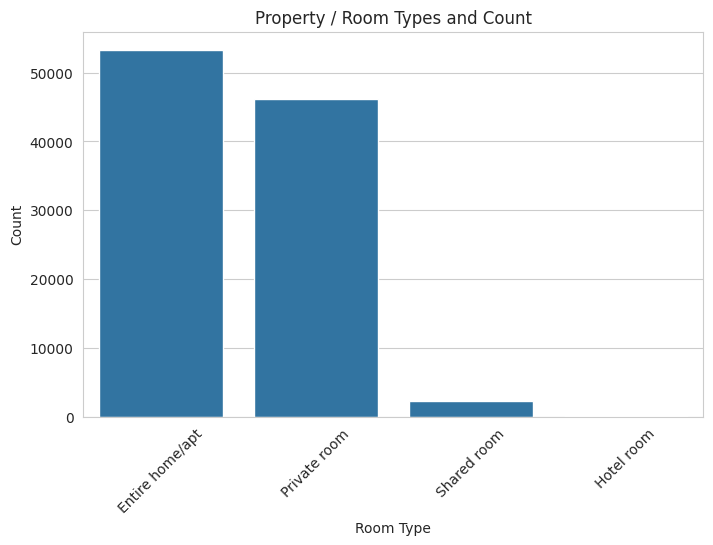

In [32]:
room_col_candidates = [c for c in df_clean.columns if 'room' in c.lower() or 'room type' in c.lower()]
room_col = room_col_candidates[0] if room_col_candidates else None
print('Detected room column:', room_col)

if room_col:
    prop_counts = df_clean[room_col].value_counts(dropna=False)
    display(prop_counts.to_frame(name='count'))
    plt.figure(figsize=(8,5))
    sns.barplot(x=prop_counts.index, y=prop_counts.values)
    plt.title('Property / Room Types and Count')
    plt.ylabel('Count')
    plt.xlabel('Room Type')
    plt.xticks(rotation=45)
    plt.show()
else:
    print('No obvious room-type column found. Columns:', df_clean.columns.tolist())


### Q2: Which neighborhood group has the highest number of listings? (bar chart)

,count
neighbourhood group,
Manhattan,43447
Brooklyn,41537
Queens,13164
Bronx,2687
Staten Island,946
nan,28
manhatan,1
brookln,1


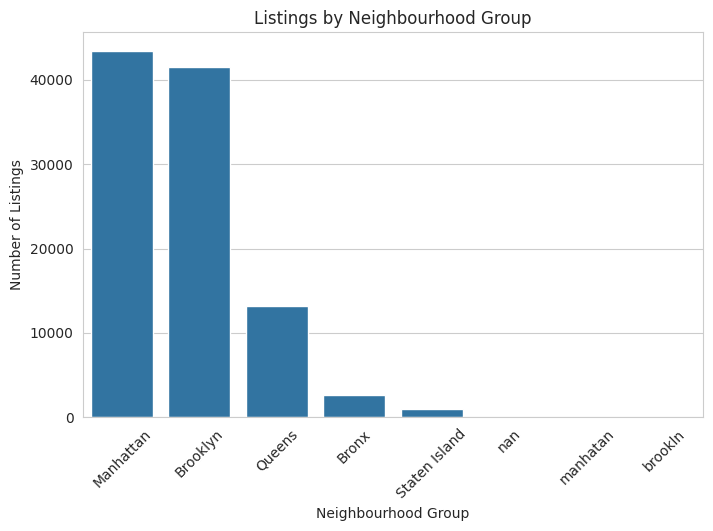

In [33]:
ng_col = None
for c in df_clean.columns:
    if c.lower().strip() in ('neighbourhood group','neighborhood group','neighbourhood_group','neighborhood_group'):
        ng_col = c
        break

if ng_col:
    ng_counts = df_clean[ng_col].value_counts()
    display(ng_counts.to_frame('count'))
    plt.figure(figsize=(8,5))
    sns.barplot(x=ng_counts.index, y=ng_counts.values)
    plt.title('Listings by Neighbourhood Group')
    plt.ylabel('Number of Listings')
    plt.xlabel('Neighbourhood Group')
    plt.xticks(rotation=45)
    plt.show()
else:
    print('Neighbourhood group column not found. Columns:', df_clean.columns.tolist())


### Q3: Which neighbourhood group has the highest average price for Airbnb listings?

,avg_price
neighbourhood group,
nan,658.357143
Queens,630.217031
Bronx,627.764793
Brooklyn,626.501962
Staten Island,623.990486
Manhattan,622.650931
brookln,580.000000
manhatan,460.000000


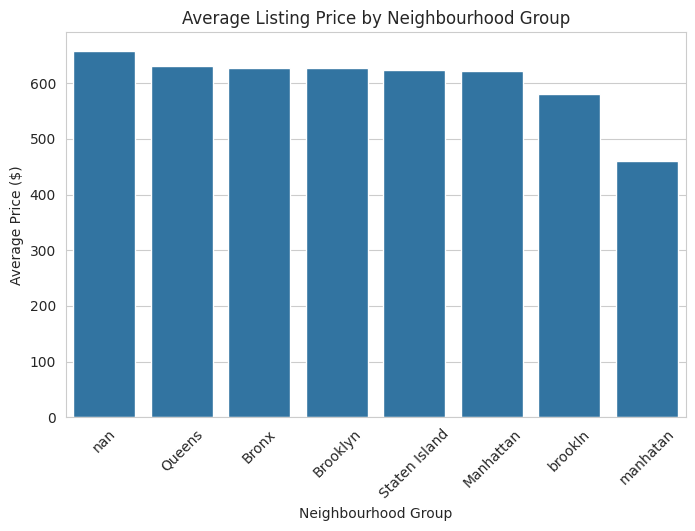

In [34]:
# find a price column
price_col = None
for c in df_clean.columns:
    if 'price' in c.lower() and 'service' not in c.lower():
        price_col = c
        break

if price_col and ng_col:
    avg_price = df_clean.groupby(ng_col)[price_col].mean().sort_values(ascending=False)
    display(avg_price.to_frame('avg_price'))
    plt.figure(figsize=(8,5))
    sns.barplot(x=avg_price.index, y=avg_price.values)
    plt.title('Average Listing Price by Neighbourhood Group')
    plt.ylabel('Average Price ($)')
    plt.xlabel('Neighbourhood Group')
    plt.xticks(rotation=45)
    plt.show()
else:
    print('Price column or neighbourhood group column missing.')


### Q4: Is there a relationship between construction year of property and price?

,Construction year,price
0,2003.0,623.282681
1,2004.0,630.038639
2,2005.0,620.240079
3,2006.0,634.960773
4,2007.0,626.194444
5,2008.0,638.667374
6,2009.0,618.610483
7,2010.0,626.627271
8,2011.0,627.247708
9,2012.0,624.084103


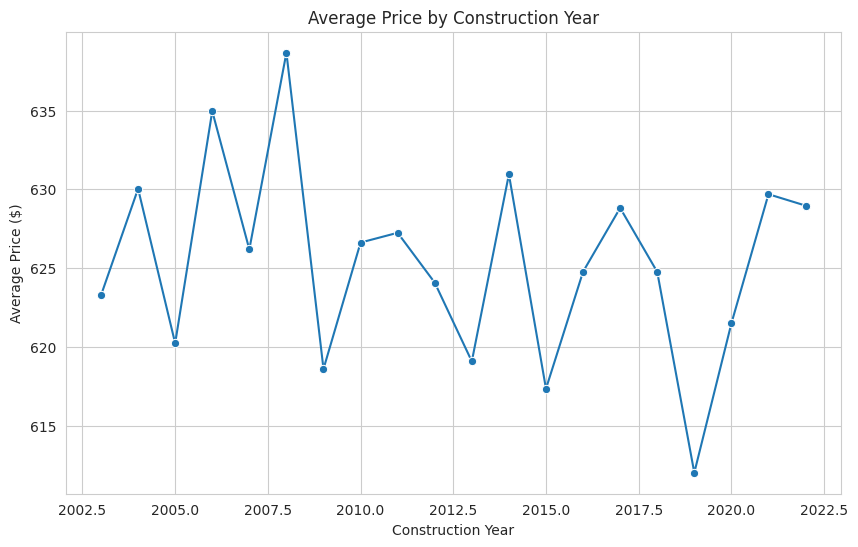

In [35]:
# Try to find a construction year column
cy_col = None
for c in df_clean.columns:
    if 'construction' in c.lower() and 'year' in c.lower():
        cy_col = c
        break

if 'construction year' in df_clean.columns:
    cy_col = 'construction year'

if cy_col and price_col:
    tmp = df_clean[[cy_col, price_col]].dropna().groupby(cy_col)[price_col].mean().reset_index()
    tmp = tmp.sort_values(by=cy_col)
    display(tmp.head(10))
    sns.lineplot(data=tmp, x=cy_col, y=price_col, marker='o')
    plt.title('Average Price by Construction Year')
    plt.xlabel('Construction Year')
    plt.ylabel('Average Price ($)')
    plt.show()
else:
    print('Construction year or price column not found. Columns:', df_clean.columns.tolist())


### Q5: Wno are the top 10 hosts by calculated host listing count?

,listings_count
host name,
Sonder (NYC),155848.0
Blueground,76484.0
Karen,43288.0
Jeniffer,32789.0
Kara,27175.0
Sonder,19680.0
Kaz,18196.0
Ken,17494.0
Corporate Housing,16744.0


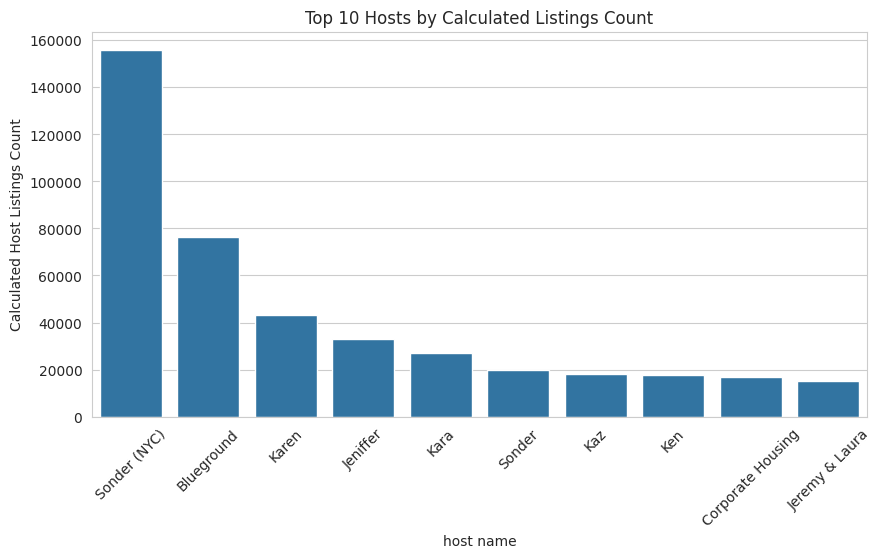

In [36]:
host_listings_col = None
for c in df_clean.columns:
    if 'calculated' in c.lower() and 'list' in c.lower():
        host_listings_col = c
        break

if host_listings_col and 'host name' in df_clean.columns:
    top_hosts = df_clean.groupby('host name')[host_listings_col].sum().sort_values(ascending=False).head(10)
    display(top_hosts.to_frame('listings_count'))
    plt.figure(figsize=(10,5))
    sns.barplot(x=top_hosts.index, y=top_hosts.values)
    plt.xticks(rotation=45)
    plt.ylabel('Calculated Host Listings Count')
    plt.title('Top 10 Hosts by Calculated Listings Count')
    plt.show()
else:
    print('calculated host listings column or host name missing. Columns:', df_clean.columns.tolist())


### Q6: Are hosts with verified identities more likely to receive positive reviews?

Detected: host_identity_verified review rate number


,avg_review
host_identity_verified,
verified,3.286212
unconfirmed,3.271830


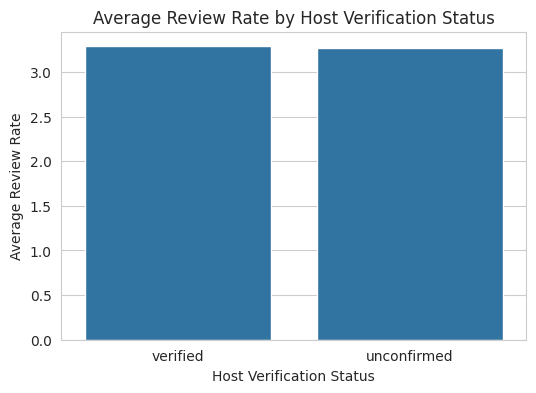

In [37]:
hid_col = None
review_col = None
for c in df_clean.columns:
    if 'identity' in c.lower() or 'verified' in c.lower():
        hid_col = c
    if 'review rate' in c.lower() or 'review_rate' in c.lower() or 'review rate number' in c.lower() or 'reviews per month' in c.lower():
        review_col = c

print('Detected:', hid_col, review_col)

if hid_col and review_col:
    review_by_verif = df_clean.groupby(hid_col)[review_col].mean().sort_values(ascending=False)
    display(review_by_verif.to_frame('avg_review'))
    plt.figure(figsize=(6,4))
    sns.barplot(x=review_by_verif.index, y=review_by_verif.values)
    plt.title('Average Review Rate by Host Verification Status')
    plt.ylabel('Average Review Rate')
    plt.xlabel('Host Verification Status')
    plt.show()
else:
    print('Verification or review column not found. Columns:', df_clean.columns.tolist())


### Q7: Is there a correlation between the price of listing and its service fee?

Pearson correlation between price and service fee: 0.9999908754521197


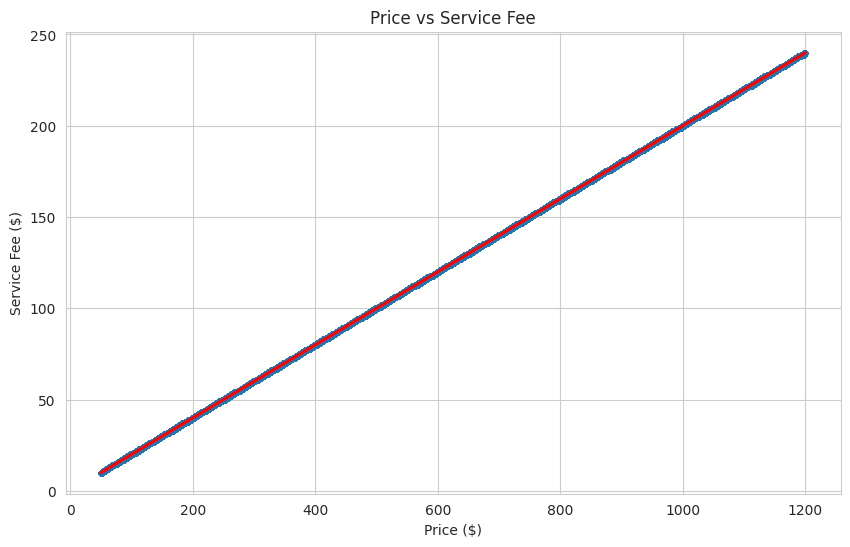

In [38]:
service_col = None
for c in df_clean.columns:
    if 'service' in c.lower() and 'fee' in c.lower():
        service_col = c
        break

if price_col and service_col:
    corr = df_clean[price_col].corr(df_clean[service_col])
    print('Pearson correlation between price and service fee:', corr)
    sns.regplot(x=df_clean[price_col], y=df_clean[service_col], scatter_kws={'s':10}, line_kws={'color':'red'})
    plt.xlabel('Price ($)')
    plt.ylabel('Service Fee ($)')
    plt.title('Price vs Service Fee')
    plt.show()
else:
    print('Price or service fee column not found. Columns:', df_clean.columns.tolist())


### Q8: What is the average review rate number (ex:stars) for listings,and does it vary based on the neighbourhood group and room type?(heatmap / barplot)

room type,Entire home/apt,Hotel room,Private room,Shared room
neighbourhood group,,,,
Bronx,3.349159,NaN,3.324482,3.260870
Brooklyn,3.249706,3.857143,3.264168,3.334559
Manhattan,3.276016,3.500000,3.277554,3.258427
Queens,3.350784,3.750000,3.315364,3.369748
Staten Island,3.331915,NaN,3.476923,3.533333
brookln,NaN,NaN,4.000000,NaN
manhatan,NaN,NaN,3.000000,NaN
nan,3.000000,NaN,3.222222,NaN


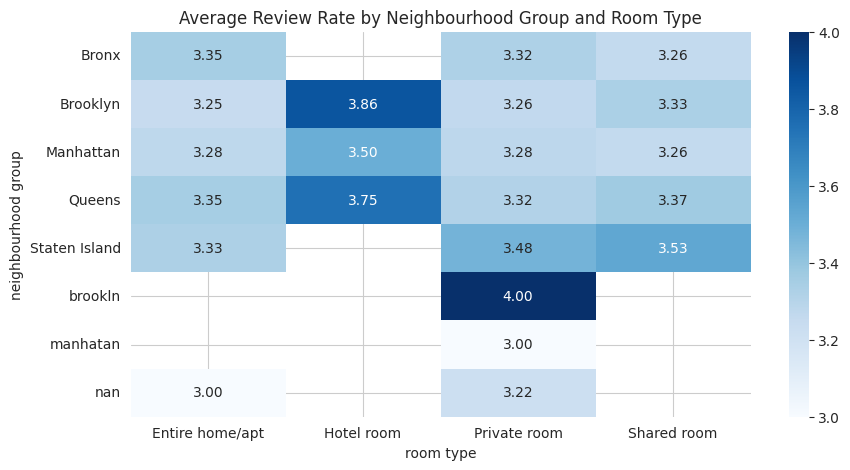

In [39]:
if 'neighbourhood group' in df_clean.columns and room_col and review_col:
    pivot = df_clean.groupby(['neighbourhood group', room_col])[review_col].mean().unstack()
    display(pivot)
    plt.figure(figsize=(10,5))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Blues')
    plt.title('Average Review Rate by Neighbourhood Group and Room Type')
    plt.show()
else:
    print('Missing one of the required columns for this plot.')


### Q9: Are hosts with higher calculated host listings count more likely to maintain higher availability throughout the year?

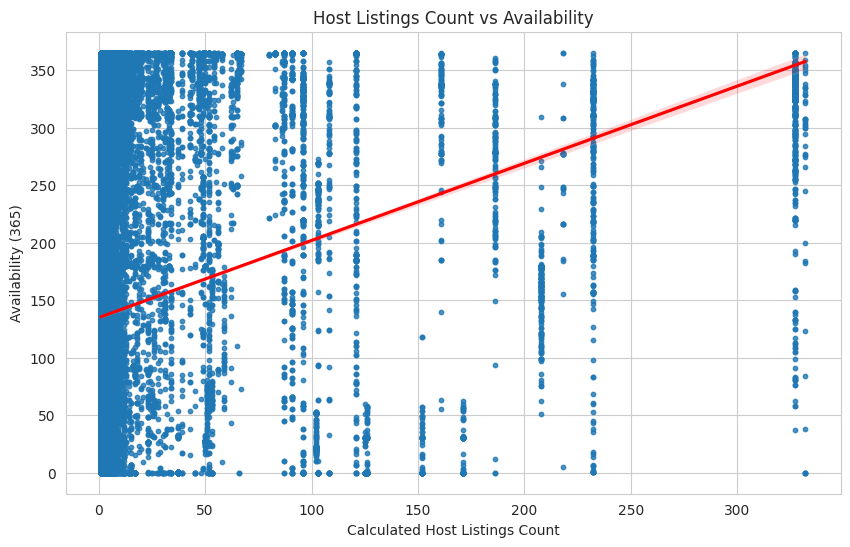

In [40]:
if host_listings_col and avail_cols:
    ac = avail_cols[0]
    sns.regplot(x=df_clean[host_listings_col], y=df_clean[ac], scatter_kws={'s':10}, line_kws={'color':'red'})
    plt.xlabel('Calculated Host Listings Count')
    plt.ylabel('Availability (365)')
    plt.title('Host Listings Count vs Availability')
    plt.show()
else:
    print('Host listings or availability column missing.')


## Conclusion

#####This notebook performed a full EDA and answered the project questions: property types, neighbourhood distribution, average prices, relationships (construction year vs price), top hosts, verification vs review rates, and price-service fee correlation. The analyses include charts and numbers.
---


In [41]:
out_csv = '/content/airbnb_cleaned.csv'
df_clean.to_csv(out_csv, index=False)
print('✅ Saved cleaned dataset to', out_csv)


✅ Saved cleaned dataset to /content/airbnb_cleaned.csv
